# Medical Imaging: Brain Tumor Segmentation with Deep Learning

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/arvidl/BMED365-2026/blob/main/Lab4-Comp-Imag/mpMRI-glioma/01_medical_imaging.ipynb)

This notebook demonstrates brain tumor segmentation using the U-Net architecture with multiparametric MRI data.


## Learning Objectives

1. Understand multiparametric MRI data for brain tumor analysis
2. Implement a 3D U-Net architecture for segmentation
3. Train and evaluate the model with Dice loss
4. Visualize and interpret segmentation results

## Prerequisites

- Basic Python and PyTorch knowledge
- Understanding of convolutional neural networks
- ~30-45 minutes to run (with GPU)

## 1. Environment Setup

In [1]:
# Check if running in Google Colab
import sys
import os

# Enable MPS fallback for 3D operations not yet implemented on Apple Silicon
# This MUST be set BEFORE importing PyTorch
os.environ['PYTORCH_ENABLE_MPS_FALLBACK'] = '1'

IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    print("Running in Google Colab - installing dependencies...")
    %pip install -q monai nibabel
    
    # Clone the repository to access src modules
    !git clone -q https://github.com/arvidl/BMED365-2026.git
    sys.path.insert(0, 'BMED365-2026/Lab4-Comp-Imag/mpMRI-glioma')
    %cd BMED365-2026/Lab4-Comp-Imag/mpMRI-glioma
else:
    # For local execution, current directory contains src/
    sys.path.insert(0, '.')

print(f"Python version: {sys.version}")

Python version: 3.10.19 | packaged by conda-forge | (main, Oct 22 2025, 22:29:10) [GCC 14.3.0]


In [2]:
# Core imports
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import random
import warnings
warnings.filterwarnings('ignore')

# Deep learning
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# Our custom modules
from src.data_utils import get_device, download_sample_data, load_mri_sample, normalize_volume
from src.visualization import plot_mri_modalities, plot_segmentation_overlay, plot_training_history
from src.models import UNet3D, UNet2D, DiceLoss, compute_dice_score

# ============================================================================
# REPRODUCIBILITY: Set all random seeds for reproducible results
# ============================================================================
SEED = 42

def set_seed(seed: int = 42):
    """Set all random seeds for reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)  # For multi-GPU
    # Make PyTorch operations deterministic
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)
print(f"Random seed set to: {SEED}")
print(f"PyTorch version: {torch.__version__}")

Random seed set to: 42
PyTorch version: 2.6.0


In [3]:
# Get the best available device
# Note: 3D convolutions (ConvTranspose3d, MaxPool3d) are not fully supported on MPS
# For 3D medical imaging, we use CPU on Apple Silicon (still fast with M-series chips)
device = get_device(force_cpu_for_3d=True)

# For Colab, ensure GPU is enabled
if IN_COLAB and not torch.cuda.is_available():
    print("\n⚠️  GPU not detected! Go to Runtime > Change runtime type > GPU")

Using CUDA: NVIDIA RTX A5000 Laptop GPU


## 2. Data Loading and Exploration

### Data Source Options

| DATA_SOURCE | Dataset | Size | Download Time | Use Case |
|-------------|---------|------|---------------|----------|
| `"github_subset"` | BRATS 50 cases | ~1.5 GB | 2-5 min | **Colab default**, demos |
| `"decathlon_full"` | Full Decathlon | ~7.5 GB | 10-30 min | Local dev, more data |

Both options provide **identical results** for this notebook because:
- Same 50 cases used: `BRATS_001` through `BRATS_050`
- Same reproducible splits with `SEED=42`: 35 train / 7 val / 8 test
- Same Decathlon data format

**Automatic selection:**
- **Colab**: Uses `github_subset` (faster download from GitHub Releases)
- **Local**: Uses `decathlon_full` (full dataset available for other experiments)

You can override this by uncommenting `DATA_SOURCE = "..."` in the configuration cell below.

In [4]:
%%time
# ============================================================================
# CONFIGURATION - EXPERIMENTAL DESIGN
# ============================================================================
# 
# This notebook follows best practices for machine learning experiments:
# 1. Proper train/validation/test splits (reproducible with SEED=42)
# 2. Early stopping to prevent overfitting
# 3. Learning rate scheduling for better convergence
# 4. Hold-out test set for unbiased evaluation
#
# ============================================================================

# DATA SOURCE OPTIONS
# -------------------
# Two options for accessing the BRATS brain tumor MRI data:
#
# Option 1: "github_subset" 
#   - Downloads only 50 cases (~1.5 GB) from GitHub Releases
#   - Fast download, perfect for demos and Colab
#   - Contains BRATS_001 through BRATS_050
#
# Option 2: "decathlon_full"
#   - Downloads full Medical Segmentation Decathlon (~7.5 GB, 484 cases)
#   - Required for publication-quality results with more data
#   - We still only use first 50 cases for reproducibility in this notebook
#
# The splits are IDENTICAL regardless of data source (same SEED, same cases)

# Automatic selection based on environment
# This repo (BMED365-2026) is public, so github_subset works for everyone!
if IN_COLAB:
    DATA_SOURCE = "github_subset"  # Fast download (~450 MB) from GitHub Release
else:
    DATA_SOURCE = "decathlon_full"  # Full dataset for local development

# Override: Uncomment ONE of these lines to force a specific data source
# DATA_SOURCE = "github_subset"    # Force GitHub subset (faster, ~450 MB)
# DATA_SOURCE = "decathlon_full"   # Force full Decathlon (~7.5 GB)

# Number of samples to use (must be <= 50 for github_subset)
MAX_SAMPLES = 50

# DATA SPLIT RATIOS (must sum to 1.0)
# These ratios + SEED ensure reproducible splits across all runs
TRAIN_RATIO = 0.70  # 70% = 35 cases for training
VAL_RATIO = 0.15    # 15% = 7 cases for validation (early stopping)
TEST_RATIO = 0.15   # 15% = 8 cases for held-out testing

# TRAINING OPTIONS
NUM_EPOCHS = 50           # Max epochs (with early stopping)
EARLY_STOPPING_PATIENCE = 10  # Stop if no improvement for N epochs
LEARNING_RATE = 1e-3      # Initial learning rate
LR_SCHEDULER = True       # Use learning rate scheduling (ReduceLROnPlateau)
LR_PATIENCE = 5           # Reduce LR if no improvement for N epochs
LR_FACTOR = 0.5           # Multiply LR by this factor when reducing

# MODEL OPTIONS
USE_PRETRAINED = True # False    # Set to True to use existing model (skip training)
PRETRAINED_MODEL_PATH = "./models/pretrained/brain_tumor_unet3d.pt"
if IN_COLAB:
    PRETRAINED_MODEL_PATH = "models/pretrained/brain_tumor_unet3d.pt"

# ============================================================================
# LOAD DATA
# ============================================================================

print("=" * 60)
print("EXPERIMENTAL CONFIGURATION")
print("=" * 60)
print(f"Environment: {'Google Colab' if IN_COLAB else 'Local'}")
print(f"Data source: {DATA_SOURCE}")
print(f"Max samples: {MAX_SAMPLES}")
print(f"Split ratios: Train={TRAIN_RATIO:.0%}, Val={VAL_RATIO:.0%}, Test={TEST_RATIO:.0%}")
print(f"Random seed: {SEED} (ensures reproducible splits)")
print("-" * 60)
print(f"Training: {NUM_EPOCHS} epochs, LR={LEARNING_RATE}")
print(f"Early stopping: patience={EARLY_STOPPING_PATIENCE}")
print(f"LR scheduler: {'Enabled' if LR_SCHEDULER else 'Disabled'}")
print(f"Use pretrained: {USE_PRETRAINED}")
print("=" * 60)

# Set data directory
base_data_dir = "./data" if not IN_COLAB else "data"

# Load data based on selected source
if DATA_SOURCE == "github_subset":
    # Fast download from GitHub Releases (~1.5 GB, 50 cases)
    from src.data_utils import download_brats_subset_github
    data_dir = download_brats_subset_github(Path(base_data_dir))
    
elif DATA_SOURCE == "decathlon_full":
    # Full Decathlon download (~7.5 GB, 484 cases available)
    print("Using full Medical Segmentation Decathlon dataset")
    data_dir = download_sample_data(data_dir=base_data_dir, dataset="decathlon")
    
else:
    raise ValueError(f"Unknown DATA_SOURCE: {DATA_SOURCE}. Use 'github_subset' or 'decathlon_full'")

# Get file list (same function works for both sources - both use Decathlon format)
from src.data_utils import get_decathlon_file_list, load_decathlon_sample
samples = get_decathlon_file_list(data_dir, max_samples=MAX_SAMPLES)
DATA_MODE = "decathlon"  # Both sources use Decathlon format

print(f"\nData directory: {data_dir}")
print(f"Number of samples: {len(samples)}")

# Verify we have the expected cases for reproducibility
if len(samples) >= 2:
    first_case = samples[0].stem.replace('.nii', '')
    last_case = samples[-1].stem.replace('.nii', '')
    print(f"Case range: {first_case} to {last_case}")
    
    if len(samples) == 50:
        expected_first, expected_last = "BRATS_001", "BRATS_050"
        if first_case == expected_first and last_case == expected_last:
            print("✓ Verified: Using BRATS_001 through BRATS_050")

EXPERIMENTAL CONFIGURATION
Environment: Local
Data source: decathlon_full
Max samples: 50
Split ratios: Train=70%, Val=15%, Test=15%
Random seed: 42 (ensures reproducible splits)
------------------------------------------------------------
Training: 50 epochs, LR=0.001
Early stopping: patience=10
LR scheduler: Enabled
Use pretrained: True
Using full Medical Segmentation Decathlon dataset
DOWNLOADING MEDICAL SEGMENTATION DECATHLON - BRAIN TUMOR
Dataset: Task01_BrainTumour
Size: ~7.5 GB download, ~16 GB extracted
Source: http://medicaldecathlon.com/


2026-01-15 00:32:52.845656: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-01-15 00:32:52.882991: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-01-15 00:32:53.783265: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Task01_BrainTumour.tar: 7.09GB [11:41, 10.8MB/s]                                

2026-01-15 00:44:37,560 - INFO - Downloaded: data/decathlon_brain/Task01_BrainTumour.tar


2026-01-15 00:44:45,696 - INFO - Verified 'Task01_BrainTumour.tar', md5: 240a19d752f0d9e9101544901065d872.
2026-01-15 00:44:45,696 - INFO - Writing into directory: data/decathlon_brain.

✓ Download complete!
Data location: data/decathlon_brain/Task01_BrainTumour
Found 50 samples in data/decathlon_brain/Task01_BrainTumour/imagesTr

Data directory: data/decathlon_brain/Task01_BrainTumour
Number of samples: 50
Case range: BRATS_001 to BRATS_050
✓ Verified: Using BRATS_001 through BRATS_050
CPU times: user 30 s, sys: 18.9 s, total: 48.9 s
Wall time: 11min 58s


In [5]:
# Load a sample to explore
if DATA_MODE == "decathlon":
    sample_data = load_decathlon_sample(samples[0])
    print(f"Sample: {samples[0].name}")
else:
    sample_data = load_mri_sample(samples[0])
    print(f"Sample: {samples[0].name}")

print("\nLoaded data:")
for key, value in sample_data.items():
    if isinstance(value, np.ndarray):
        print(f"  {key}: shape={value.shape}, dtype={value.dtype}, range=[{value.min():.3f}, {value.max():.3f}]")

Sample: BRATS_001.nii.gz

Loaded data:
  image: shape=(4, 155, 240, 240), dtype=float32, range=[0.000, 2239.000]
  flair: shape=(155, 240, 240), dtype=float64, range=[0.000, 1829.000]
  t1: shape=(155, 240, 240), dtype=float64, range=[0.000, 2155.000]
  t1ce: shape=(155, 240, 240), dtype=float64, range=[0.000, 2239.000]
  t2: shape=(155, 240, 240), dtype=float64, range=[0.000, 1669.000]
  seg: shape=(155, 240, 240), dtype=uint8, range=[0.000, 3.000]


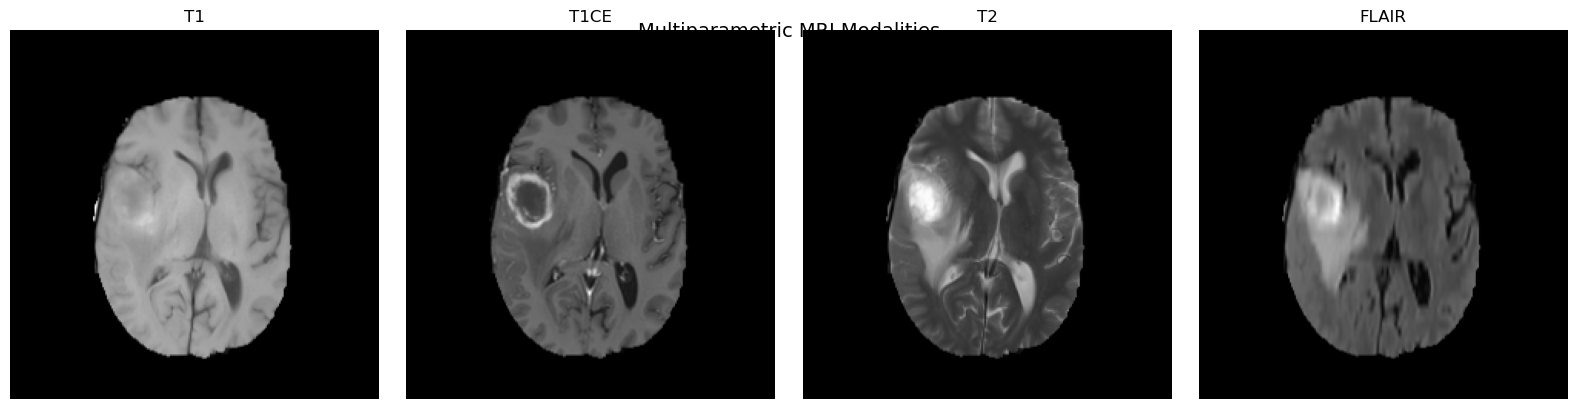

In [6]:
# Visualize MRI modalities
# For Decathlon data with shape (D, H, W), axis=0 gives axial slices
# Choose middle axial slice (along D dimension)
if 'flair' in sample_data:
    slice_idx = sample_data['flair'].shape[0] // 2  # Middle of D dimension
else:
    slice_idx = sample_data['image'].shape[1] // 2  # D is dim 1 for (C,D,H,W)

fig = plot_mri_modalities(sample_data, slice_idx=slice_idx, axis=0)
plt.suptitle("Multiparametric MRI Modalities", fontsize=14)
plt.show()

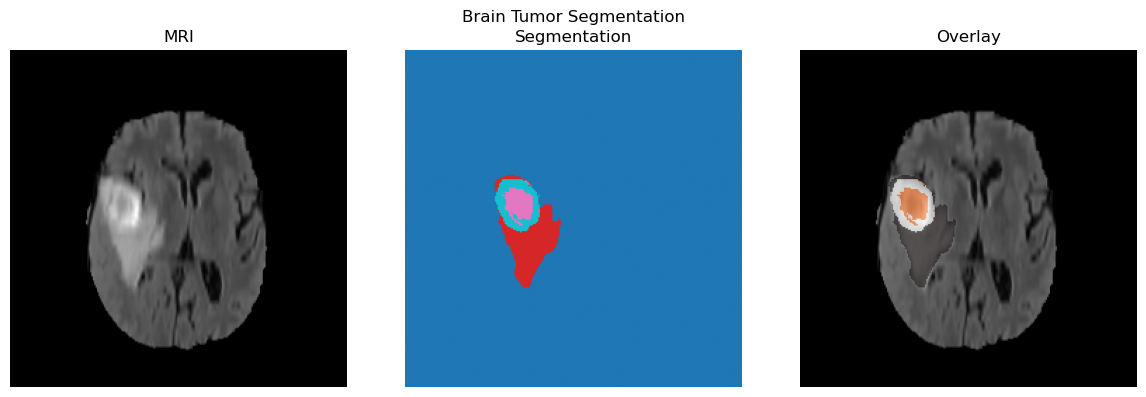


Segmentation class distribution:
  Background: 8,816,276 voxels (98.7%)
  Necrotic/Core: 53,050 voxels (0.6%)
  Edema: 27,189 voxels (0.3%)
  Enhancing: 31,485 voxels (0.4%)


In [7]:
# Visualize segmentation overlay (axis=0 for axial slices)
fig = plot_segmentation_overlay(
    sample_data['flair'], 
    sample_data['seg'],
    slice_idx=slice_idx,
    axis=0,  # Axial slices along D dimension
    title="Brain Tumor Segmentation"
)
plt.show()

# Show segmentation class distribution
unique, counts = np.unique(sample_data['seg'], return_counts=True)
print("\nSegmentation class distribution:")
class_names = {0: "Background", 1: "Necrotic/Core", 2: "Edema", 3: "Enhancing"}
for u, c in zip(unique, counts):
    name = class_names.get(u, f"Class {u}")
    print(f"  {name}: {c:,} voxels ({100*c/counts.sum():.1f}%)")

## 3. Dataset and DataLoader

We create a PyTorch Dataset that handles loading, preprocessing, and augmentation of the MRI data.

In [8]:
class BrainTumorDataset(Dataset):
    """
    Dataset for brain tumor segmentation.
    
    Supports both synthetic data and real Decathlon data.
    Loads multiparametric MRI (T1, T1ce, T2, FLAIR) and segmentation masks.
    """
    
    def __init__(self, sample_paths, data_mode="synthetic", augment=False, target_shape=None):
        """
        Args:
            sample_paths: List of paths to samples
            data_mode: "synthetic" or "decathlon"
            augment: Whether to apply data augmentation
            target_shape: Optional (D, H, W) to resize volumes (useful for real data)
        """
        self.sample_paths = sample_paths
        self.data_mode = data_mode
        self.augment = augment
        self.target_shape = target_shape
        self.modalities = ['t1', 't1ce', 't2', 'flair']
    
    def __len__(self):
        return len(self.sample_paths)
    
    def __getitem__(self, idx):
        sample_path = self.sample_paths[idx]
        
        # Load data based on mode
        if self.data_mode == "decathlon":
            data = load_decathlon_sample(sample_path)
            # Decathlon provides pre-stacked 4-channel image
            image = data['image']  # Already (4, D, H, W)
            label = data['seg']
            name = sample_path.stem
        else:
            # Synthetic data
            data = load_mri_sample(sample_path)
            image = np.stack([normalize_volume(data[mod]) for mod in self.modalities], axis=0)
            label = data['seg']
            name = sample_path.name
        
        # Normalize each channel
        for c in range(image.shape[0]):
            channel = image[c]
            mask = channel > 0
            if mask.sum() > 0:
                mean = channel[mask].mean()
                std = channel[mask].std() + 1e-8
                image[c] = np.where(mask, (channel - mean) / std, 0)
        
        # Optional: resize to target shape (for memory efficiency with real data)
        if self.target_shape is not None:
            from scipy.ndimage import zoom
            current_shape = image.shape[1:]  # (D, H, W)
            zoom_factors = [t / c for t, c in zip(self.target_shape, current_shape)]
            
            # Resize image channels
            resized_image = np.zeros((4,) + self.target_shape, dtype=np.float32)
            for c in range(4):
                resized_image[c] = zoom(image[c], zoom_factors, order=1)
            image = resized_image
            
            # Resize label (use nearest neighbor for segmentation)
            label = zoom(label.astype(np.float32), zoom_factors, order=0).astype(np.uint8)
        
        # Simple augmentation: random flips
        if self.augment:
            if np.random.rand() > 0.5:
                image = np.flip(image, axis=-1).copy()
                label = np.flip(label, axis=-1).copy()
            if np.random.rand() > 0.5:
                image = np.flip(image, axis=-2).copy()
                label = np.flip(label, axis=-2).copy()
        
        return {
            'image': torch.from_numpy(image.copy()).float(),
            'label': torch.from_numpy(label.copy()).long(),
            'name': name
        }

In [9]:
# ============================================================================
# DATA SPLITTING: Train / Validation / Test
# ============================================================================
# 
# REPRODUCIBILITY GUARANTEE:
# The same 50 cases (BRATS_001-BRATS_050) with SEED=42 always produce 
# these exact splits, regardless of whether data comes from GitHub subset 
# or full Decathlon download:
#
#   - Training (35 cases): BRATS_026, BRATS_024, BRATS_020, ...
#   - Validation (7 cases): BRATS_050, BRATS_048, BRATS_003, BRATS_028, ...
#   - Test (8 cases): BRATS_007, BRATS_009, BRATS_015, BRATS_016, ...
#
# This prevents overfitting to the validation set during hyperparameter tuning
# and gives an unbiased estimate of generalization performance.
#
# ============================================================================

# Shuffle samples with fixed seed for reproducibility
shuffled_samples = samples.copy()
random.seed(SEED)
random.shuffle(shuffled_samples)

# Calculate split sizes
n_total = len(shuffled_samples)
n_train = int(n_total * TRAIN_RATIO)
n_val = int(n_total * VAL_RATIO)
n_test = n_total - n_train - n_val  # Remaining goes to test

# Ensure at least 1 sample in each split
n_train = max(1, n_train)
n_val = max(1, n_val)
n_test = max(1, n_test)

# Split the data
train_samples = shuffled_samples[:n_train]
val_samples = shuffled_samples[n_train:n_train + n_val]
test_samples = shuffled_samples[n_train + n_val:]

# Store test samples for later evaluation (kept separate from training process)
TEST_SAMPLES = test_samples  # Global reference for final evaluation

# Resize for memory efficiency: 240x240x155 → 128x128x128
TARGET_SHAPE = (128, 128, 128)

# Helper function to get case ID from path
def get_case_id(path):
    return path.stem.replace('.nii', '')

# Get case IDs for each split
train_ids = [get_case_id(s) for s in train_samples]
val_ids = [get_case_id(s) for s in val_samples]
test_ids = [get_case_id(s) for s in test_samples]

print("=" * 60)
print("DATA SPLIT SUMMARY")
print("=" * 60)
print(f"Total samples: {n_total}")
print(f"Training: {len(train_samples)} ({len(train_samples)/n_total:.1%})")
print(f"Validation: {len(val_samples)} ({len(val_samples)/n_total:.1%})")
print(f"Test (HELD OUT): {len(test_samples)} ({len(test_samples)/n_total:.1%})")
print("-" * 60)
print(f"Train IDs: {', '.join(train_ids[:5])}... ({len(train_ids)} total)")
print(f"Val IDs: {', '.join(val_ids)}")
print(f"Test IDs: {', '.join(test_ids)}")

# Reproducibility verification (for 50 samples with SEED=42)
if n_total == 50 and SEED == 42:
    expected_test_ids = ['BRATS_007', 'BRATS_009', 'BRATS_015', 'BRATS_016', 
                         'BRATS_018', 'BRATS_002', 'BRATS_008', 'BRATS_041']
    if test_ids == expected_test_ids:
        print("\n✓ Split verification PASSED: Matches expected test set")
    else:
        print(f"\n⚠ Split verification: Test IDs differ from expected")
        print(f"  Expected: {expected_test_ids}")
        print(f"  Got: {test_ids}")

print("\n⚠️  Test set will NOT be used during training!")
print(f"Resizing volumes to: {TARGET_SHAPE}")
print("=" * 60)

# Create datasets (training and validation only - test is reserved)
train_dataset = BrainTumorDataset(
    train_samples, 
    data_mode=DATA_MODE, 
    augment=True,
    target_shape=TARGET_SHAPE
)
val_dataset = BrainTumorDataset(
    val_samples, 
    data_mode=DATA_MODE, 
    augment=False,
    target_shape=TARGET_SHAPE
)
# Note: test_dataset will be created later for final evaluation

# Create dataloaders with reproducible shuffling
batch_size = 1  # Small batch for 3D volumes

# Generator for reproducible shuffling
g = torch.Generator()
g.manual_seed(SEED)

train_loader = DataLoader(
    train_dataset, 
    batch_size=batch_size, 
    shuffle=True,
    generator=g  # Reproducible shuffling
)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

DATA SPLIT SUMMARY
Total samples: 50
Training: 35 (70.0%)
Validation: 7 (14.0%)
Test (HELD OUT): 8 (16.0%)
------------------------------------------------------------
Train IDs: BRATS_026, BRATS_024, BRATS_020, BRATS_012, BRATS_005... (35 total)
Val IDs: BRATS_050, BRATS_048, BRATS_003, BRATS_028, BRATS_038, BRATS_006, BRATS_035
Test IDs: BRATS_007, BRATS_009, BRATS_015, BRATS_016, BRATS_018, BRATS_002, BRATS_008, BRATS_041

✓ Split verification PASSED: Matches expected test set

⚠️  Test set will NOT be used during training!
Resizing volumes to: (128, 128, 128)


In [10]:
# Verify data loading
batch = next(iter(train_loader))
print(f"Image batch shape: {batch['image'].shape}")
print(f"Label batch shape: {batch['label'].shape}")
print(f"Sample name: {batch['name']}")

Image batch shape: torch.Size([1, 4, 128, 128, 128])
Label batch shape: torch.Size([1, 128, 128, 128])
Sample name: ['BRATS_022.nii']


## 4. Model Architecture

We use a 3D U-Net architecture with encoder-decoder structure and skip connections.

In [11]:
# Number of segmentation classes depends on data mode
# - Synthetic (brats_sample): 2 classes (background + tumor)
# - Decathlon real data: 4 classes (background, necrotic, edema, enhancing)
NUM_CLASSES = 4 if DATA_MODE == "decathlon" else 2
print(f"Number of segmentation classes: {NUM_CLASSES}")

# Initialize model
model = UNet3D(
    in_channels=4,          # T1, T1ce, T2, FLAIR
    out_channels=NUM_CLASSES,  # Segmentation classes
    base_features=16,       # Reduced for memory efficiency
    depth=3                 # Reduced depth for small volumes
).to(device)

# Count parameters
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model parameters: {n_params:,}")

# Load pretrained weights if available and requested
PRETRAINED_LOADED = False
if USE_PRETRAINED:
    pretrained_path = Path(PRETRAINED_MODEL_PATH)
    if pretrained_path.exists():
        print(f"\nLoading pretrained model from: {pretrained_path}")
        checkpoint = torch.load(pretrained_path, map_location=device, weights_only=False)
        model.load_state_dict(checkpoint['model_state_dict'])
        print(f"  ✓ Loaded model trained for {checkpoint['epoch']} epochs")
        print(f"  ✓ Best validation Dice: {checkpoint.get('best_dice', 'N/A')}")
        PRETRAINED_LOADED = True
    else:
        print(f"\n⚠ Pretrained model not found at: {pretrained_path}")
        print("  Will train from scratch. After training, save the model to use next time.")
else:
    print("\nUSE_PRETRAINED=False: Will train model from scratch")

Number of segmentation classes: 4
Model parameters: 1,403,316

Loading pretrained model from: models/pretrained/brain_tumor_unet3d.pt
  ✓ Loaded model trained for 18 epochs
  ✓ Best validation Dice: 0.9908804893493652


In [12]:
# Test forward pass
with torch.no_grad():
    test_input = batch['image'].to(device)
    test_output = model(test_input)
    print(f"Input shape: {test_input.shape}")
    print(f"Output shape: {test_output.shape}")

Input shape: torch.Size([1, 4, 128, 128, 128])
Output shape: torch.Size([1, 4, 128, 128, 128])


## 5. Training

We train the model using Dice loss, which is well-suited for segmentation tasks with class imbalance.

In [13]:
# ============================================================================
# LOSS FUNCTION, OPTIMIZER, AND SCHEDULERS
# ============================================================================

# Loss function: Dice Loss is ideal for segmentation with class imbalance
# - The tumor region is much smaller than background
# - Dice loss directly optimizes the metric we care about
criterion = DiceLoss(smooth=1e-5, include_background=False)

# Optimizer: Adam with configurable learning rate
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# Learning rate scheduler: Reduce LR when validation loss plateaus
# - This helps fine-tune the model as training progresses
# - Prevents overshooting the optimal solution
if LR_SCHEDULER:
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, 
        mode='min',              # Minimize validation loss
        patience=LR_PATIENCE,    # Wait N epochs before reducing
        factor=LR_FACTOR         # Multiply LR by this factor
    )
    print(f"LR Scheduler: ReduceLROnPlateau (patience={LR_PATIENCE}, factor={LR_FACTOR})")
else:
    scheduler = None
    print("LR Scheduler: Disabled")

print(f"Optimizer: Adam (lr={LEARNING_RATE})")
print(f"Loss function: DiceLoss (exclude background)")

# ============================================================================
# EARLY STOPPING
# ============================================================================
# Early stopping prevents overfitting by stopping training when validation
# performance stops improving. This saves computation and prevents memorizing
# the training data at the expense of generalization.

class EarlyStopping:
    """
    Early stopping to prevent overfitting.
    
    Monitors a metric (e.g., validation Dice) and stops training if it
    doesn't improve for 'patience' epochs.
    """
    
    def __init__(self, patience=10, mode='max', min_delta=0.001):
        """
        Args:
            patience: Number of epochs to wait for improvement
            mode: 'max' for metrics to maximize (Dice), 'min' to minimize (loss)
            min_delta: Minimum change to qualify as improvement
        """
        self.patience = patience
        self.mode = mode
        self.min_delta = min_delta
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.best_model_state = None
        
    def __call__(self, score, model):
        if self.best_score is None:
            self.best_score = score
            self.best_model_state = model.state_dict().copy()
            return False
        
        if self.mode == 'max':
            improved = score > self.best_score + self.min_delta
        else:
            improved = score < self.best_score - self.min_delta
        
        if improved:
            self.best_score = score
            self.best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
                return True
        
        return False
    
    def restore_best_model(self, model):
        """Restore model weights to best seen during training."""
        if self.best_model_state is not None:
            model.load_state_dict(self.best_model_state)
            print(f"Restored best model (Dice: {self.best_score:.4f})")

# Initialize early stopping
early_stopping = EarlyStopping(patience=EARLY_STOPPING_PATIENCE, mode='max')
print(f"Early stopping: patience={EARLY_STOPPING_PATIENCE} epochs")

LR Scheduler: ReduceLROnPlateau (patience=5, factor=0.5)
Optimizer: Adam (lr=0.001)
Loss function: DiceLoss (exclude background)
Early stopping: patience=10 epochs


In [14]:
def train_epoch(model, loader, criterion, optimizer, device):
    """Train for one epoch."""
    model.train()
    total_loss = 0
    
    for batch in loader:
        images = batch['image'].to(device)
        labels = batch['label'].to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    return total_loss / len(loader)


def validate(model, loader, criterion, device):
    """Validate the model."""
    model.eval()
    total_loss = 0
    dice_scores = []
    
    with torch.no_grad():
        for batch in loader:
            images = batch['image'].to(device)
            labels = batch['label'].to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            
            # Compute Dice score
            preds = outputs.argmax(dim=1)
            dice = compute_dice_score(preds, labels)
            dice_scores.append(dice)
    
    return total_loss / len(loader), np.mean(dice_scores)

In [15]:
%%time
# ============================================================================
# TRAINING LOOP WITH EARLY STOPPING AND LR SCHEDULING
# ============================================================================
#
# Key features:
# 1. Early stopping: Stop if validation Dice doesn't improve for N epochs
# 2. LR scheduling: Reduce learning rate when progress stalls
# 3. Best model tracking: Restore best weights at the end
# 4. Comprehensive logging: Track all metrics for analysis
#
# ============================================================================

history = {
    'train_loss': [], 
    'val_loss': [], 
    'val_dice': [],
    'learning_rate': []  # Track LR changes
}

if PRETRAINED_LOADED:
    print("=" * 60)
    print("SKIPPING TRAINING: Using pretrained model")
    print("Set USE_PRETRAINED = False in configuration to retrain")
    print("=" * 60)
else:
    print("=" * 60)
    print("TRAINING STARTED")
    print("=" * 60)
    print(f"Epochs: {NUM_EPOCHS} (with early stopping, patience={EARLY_STOPPING_PATIENCE})")
    print(f"Training samples: {len(train_samples)}")
    print(f"Validation samples: {len(val_samples)}")
    print(f"Test samples (held out): {len(test_samples)}")
    print("-" * 60)
    
    # Reset early stopping
    early_stopping = EarlyStopping(patience=EARLY_STOPPING_PATIENCE, mode='max')
    
    best_dice = 0.0
    stopped_epoch = NUM_EPOCHS
    
    for epoch in range(NUM_EPOCHS):
        # Training phase
        train_loss = train_epoch(model, train_loader, criterion, optimizer, device)
        
        # Validation phase
        val_loss, val_dice = validate(model, val_loader, criterion, device)
        
        # Learning rate scheduling
        current_lr = optimizer.param_groups[0]['lr']
        if scheduler is not None:
            scheduler.step(val_loss)
        
        # Record history
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_dice'].append(val_dice)
        history['learning_rate'].append(current_lr)
        
        # Track best model
        if val_dice > best_dice:
            best_dice = val_dice
        
        # Print progress
        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"Epoch {epoch+1:3d}/{NUM_EPOCHS} | "
                  f"Train Loss: {train_loss:.4f} | "
                  f"Val Loss: {val_loss:.4f} | "
                  f"Val Dice: {val_dice:.4f} | "
                  f"LR: {current_lr:.2e}")
        
        # Early stopping check
        if early_stopping(val_dice, model):
            stopped_epoch = epoch + 1
            print("-" * 60)
            print(f"⚡ Early stopping triggered at epoch {stopped_epoch}")
            print(f"   No improvement for {EARLY_STOPPING_PATIENCE} epochs")
            break
    
    # Restore best model weights
    print("-" * 60)
    early_stopping.restore_best_model(model)
    
    print(f"\n✓ Training complete!")
    print(f"  Total epochs: {stopped_epoch} / {NUM_EPOCHS}")
    print(f"  Best validation Dice: {best_dice:.4f}")
    
    # Save trained model with comprehensive metadata
    save_path = Path(PRETRAINED_MODEL_PATH)
    save_path.parent.mkdir(parents=True, exist_ok=True)
    
    # Record training configuration for reproducibility
    training_config = {
        'num_epochs_trained': stopped_epoch,
        'num_epochs_max': NUM_EPOCHS,
        'early_stopping_patience': EARLY_STOPPING_PATIENCE,
        'learning_rate_initial': LEARNING_RATE,
        'lr_scheduler': LR_SCHEDULER,
        'lr_patience': LR_PATIENCE if LR_SCHEDULER else None,
        'lr_factor': LR_FACTOR if LR_SCHEDULER else None,
        'train_ratio': TRAIN_RATIO,
        'val_ratio': VAL_RATIO,
        'test_ratio': TEST_RATIO,
        'n_train_samples': len(train_samples),
        'n_val_samples': len(val_samples),
        'n_test_samples': len(test_samples),
        'random_seed': SEED,
    }
    
    # Save case IDs for each split
    if DATA_MODE == "decathlon":
        training_config['train_case_ids'] = [s.stem.replace('.nii', '') for s in train_samples]
        training_config['val_case_ids'] = [s.stem.replace('.nii', '') for s in val_samples]
        training_config['test_case_ids'] = [s.stem.replace('.nii', '') for s in test_samples]
    
    checkpoint = {
        'epoch': stopped_epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'best_dice': best_dice,
        'history': history,
        'config': {
            'in_channels': 4,
            'out_channels': NUM_CLASSES,
            'base_features': 16,
            'depth': 3,
            'data_mode': DATA_MODE,
            'target_shape': TARGET_SHAPE,
        },
        'training_config': training_config,
    }
    torch.save(checkpoint, save_path)
    print(f"\n✓ Model saved to: {save_path}")
    print(f"  File size: {save_path.stat().st_size / 1024 / 1024:.2f} MB")
    print("=" * 60)

SKIPPING TRAINING: Using pretrained model
Set USE_PRETRAINED = False in configuration to retrain
CPU times: user 42 µs, sys: 0 ns, total: 42 µs
Wall time: 36.5 µs


Showing training history from pretrained model checkpoint

Training configuration:
  Epochs trained: 18
  Train/Val/Test split: 70%/15%/15%
  Samples: Train=35, Val=7, Test=8


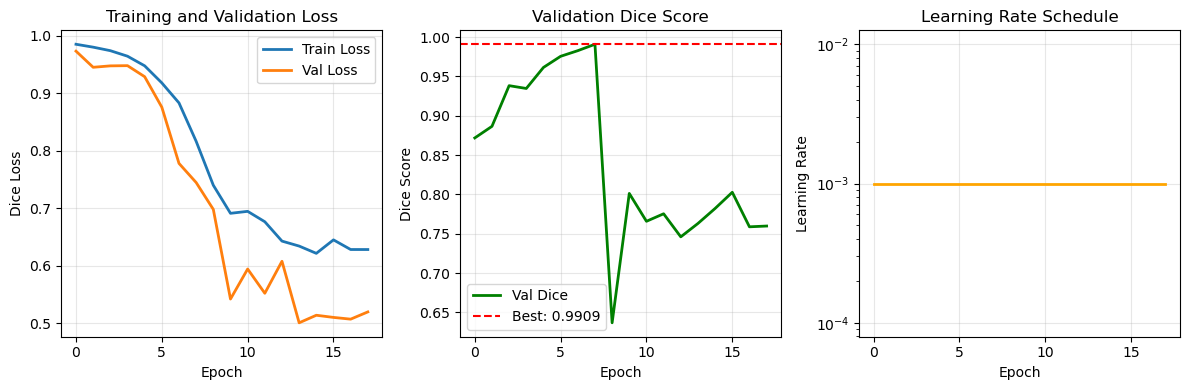


Training Summary:
  Total epochs: 18
  Final train loss: 0.6283
  Final val loss: 0.5200
  Best val Dice: 0.9909
  Final LR: 1.00e-03


In [16]:
# ============================================================================
# TRAINING HISTORY VISUALIZATION
# ============================================================================
# Visualize the training process to:
# 1. Check for overfitting (train vs. val divergence)
# 2. Verify learning rate scheduling worked
# 3. Identify optimal stopping point
# ============================================================================

if PRETRAINED_LOADED:
    # Try to load history from checkpoint
    checkpoint = torch.load(PRETRAINED_MODEL_PATH, map_location='cpu', weights_only=False)
    if 'history' in checkpoint and checkpoint['history'].get('train_loss'):
        history = checkpoint['history']
        print("Showing training history from pretrained model checkpoint")
        
        # Show training configuration if available
        if 'training_config' in checkpoint:
            tc = checkpoint['training_config']
            print(f"\nTraining configuration:")
            print(f"  Epochs trained: {tc.get('num_epochs_trained', 'N/A')}")
            print(f"  Train/Val/Test split: {tc.get('train_ratio', 'N/A'):.0%}/{tc.get('val_ratio', 'N/A'):.0%}/{tc.get('test_ratio', 'N/A'):.0%}")
            print(f"  Samples: Train={tc.get('n_train_samples', 'N/A')}, Val={tc.get('n_val_samples', 'N/A')}, Test={tc.get('n_test_samples', 'N/A')}")
    else:
        print("Training history not available in pretrained checkpoint")
        print("Set USE_PRETRAINED = False and retrain to see training curves")

if history.get('train_loss'):
    # Determine number of subplots based on available data
    n_plots = 3 if history.get('learning_rate') else 2
    fig, axes = plt.subplots(1, n_plots, figsize=(4*n_plots, 4))
    
    # Plot 1: Loss curves
    axes[0].plot(history['train_loss'], label='Train Loss', linewidth=2)
    axes[0].plot(history['val_loss'], label='Val Loss', linewidth=2)
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Dice Loss')
    axes[0].set_title('Training and Validation Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Plot 2: Dice score
    axes[1].plot(history['val_dice'], label='Val Dice', color='green', linewidth=2)
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Dice Score')
    axes[1].set_title('Validation Dice Score')
    axes[1].axhline(y=max(history['val_dice']), color='red', linestyle='--', 
                    label=f"Best: {max(history['val_dice']):.4f}")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    # Plot 3: Learning rate (if available)
    if n_plots == 3:
        axes[2].plot(history['learning_rate'], color='orange', linewidth=2)
        axes[2].set_xlabel('Epoch')
        axes[2].set_ylabel('Learning Rate')
        axes[2].set_title('Learning Rate Schedule')
        axes[2].set_yscale('log')
        axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Print training summary
    print(f"\nTraining Summary:")
    print(f"  Total epochs: {len(history['train_loss'])}")
    print(f"  Final train loss: {history['train_loss'][-1]:.4f}")
    print(f"  Final val loss: {history['val_loss'][-1]:.4f}")
    print(f"  Best val Dice: {max(history['val_dice']):.4f}")
    if history.get('learning_rate'):
        print(f"  Final LR: {history['learning_rate'][-1]:.2e}")
else:
    print("No training history to display")

## 5.1 Hold-Out Test Set Evaluation

**Critical Step**: Evaluate on the held-out test set that was **never seen during training or hyperparameter tuning**.

This provides an unbiased estimate of how the model will perform on new, unseen data.

| Split | Purpose | Used During Training? |
|-------|---------|----------------------|
| Training | Update model weights | ✓ Yes |
| Validation | Early stopping, LR scheduling | ✓ Yes (indirectly) |
| **Test** | **Final unbiased evaluation** | **✗ NO** |

⚠️ **Warning**: The test set should only be evaluated ONCE, at the very end of the project. Repeatedly evaluating on the test set and making changes based on the results introduces bias.

In [17]:
# ============================================================================
# HOLD-OUT TEST SET EVALUATION
# ============================================================================
# This is the final, unbiased evaluation on data the model has NEVER seen.
# ============================================================================

def predict_sample(model, sample_path, device, data_mode, target_shape):
    """
    Run inference on a single sample.
    
    This is a standalone prediction function for test evaluation.
    """
    model.eval()
    
    # Load data based on mode
    if data_mode == "decathlon":
        from src.data_utils import load_decathlon_sample
        data = load_decathlon_sample(sample_path)
        image = data['image']  # Already (4, D, H, W)
    else:
        data = load_mri_sample(sample_path)
        modalities = ['t1', 't1ce', 't2', 'flair']
        image = np.stack([normalize_volume(data[mod]) for mod in modalities], axis=0)
    
    # Normalize each channel
    for c in range(image.shape[0]):
        channel = image[c]
        mask = channel > 0
        if mask.sum() > 0:
            mean = channel[mask].mean()
            std = channel[mask].std() + 1e-8
            image[c] = np.where(mask, (channel - mean) / std, 0)
    
    # Resize if needed (for Decathlon data)
    if target_shape is not None:
        from scipy.ndimage import zoom
        current_shape = image.shape[1:]  # (D, H, W)
        zoom_factors = [t / c for t, c in zip(target_shape, current_shape)]
        image = np.stack([zoom(image[c], zoom_factors, order=1) for c in range(4)], axis=0)
    
    image_tensor = torch.from_numpy(image).float().unsqueeze(0).to(device)
    
    # Predict
    with torch.no_grad():
        output = model(image_tensor)
        pred = output.argmax(dim=1).squeeze().cpu().numpy()
    
    return data, pred


def evaluate_on_test_set(model, test_samples, device, data_mode, target_shape):
    """
    Evaluate model on held-out test set.
    
    Returns per-sample metrics and aggregate statistics.
    """
    model.eval()
    
    results = []
    
    for sample_path in test_samples:
        # Get case ID
        case_id = sample_path.stem.replace('.nii', '')
        
        # Run prediction
        data, pred = predict_sample(model, sample_path, device, data_mode, target_shape)
        
        # Get ground truth and resize if needed
        seg = data['seg']
        if target_shape is not None:
            from scipy.ndimage import zoom
            zoom_factors = [t / c for t, c in zip(target_shape, seg.shape)]
            seg = zoom(seg, zoom_factors, order=0)  # order=0 for nearest neighbor
        
        # Convert to binary for Dice calculation (tumor vs background)
        pred_binary = (pred > 0).astype(float)
        seg_binary = (seg > 0).astype(float)
        
        # Calculate Dice score
        intersection = (pred_binary * seg_binary).sum()
        dice = (2 * intersection + 1e-5) / (pred_binary.sum() + seg_binary.sum() + 1e-5)
        
        # Calculate per-class Dice if multi-class
        class_dice = {}
        if data_mode == "decathlon":
            class_names = {1: 'Necrotic', 2: 'Edema', 3: 'Enhancing'}
            for cls, name in class_names.items():
                pred_cls = (pred == cls).astype(float)
                seg_cls = (seg == cls).astype(float)
                inter = (pred_cls * seg_cls).sum()
                d = (2 * inter + 1e-5) / (pred_cls.sum() + seg_cls.sum() + 1e-5)
                class_dice[name] = d
        
        results.append({
            'case_id': case_id,
            'dice': dice,
            **class_dice
        })
        
    return results

# Only run test evaluation if test samples exist
if len(test_samples) > 0:
    print("=" * 60)
    print("HOLD-OUT TEST SET EVALUATION")
    print("=" * 60)
    print(f"⚠️  Evaluating on {len(test_samples)} held-out test samples")
    print("    These samples were NEVER used during training!")
    print("-" * 60)
    
    # Run evaluation
    test_results = evaluate_on_test_set(
        model, test_samples, device, DATA_MODE, TARGET_SHAPE
    )
    
    # Convert to DataFrame for nice display
    import pandas as pd
    results_df = pd.DataFrame(test_results)
    
    # Display per-sample results
    print("\nPer-sample Dice scores:")
    print(results_df.to_string(index=False))
    
    # Aggregate statistics
    print("\n" + "-" * 60)
    print("AGGREGATE TEST SET METRICS:")
    print("-" * 60)
    
    mean_dice = results_df['dice'].mean()
    std_dice = results_df['dice'].std()
    print(f"  Overall Dice: {mean_dice:.4f} ± {std_dice:.4f}")
    
    # Per-class metrics if available
    if 'Necrotic' in results_df.columns:
        print(f"\n  Per-class Dice scores:")
        for cls in ['Necrotic', 'Edema', 'Enhancing']:
            if cls in results_df.columns:
                m = results_df[cls].mean()
                s = results_df[cls].std()
                print(f"    {cls}: {m:.4f} ± {s:.4f}")
    
    print("-" * 60)
    
    # Compare with validation performance
    if history.get('val_dice'):
        best_val_dice = max(history['val_dice'])
        print(f"\n  Comparison with Validation:")
        print(f"    Best Val Dice: {best_val_dice:.4f}")
        print(f"    Test Dice:     {mean_dice:.4f}")
        diff = mean_dice - best_val_dice
        if diff < -0.05:
            print(f"    ⚠️  Test performance is lower (diff: {diff:.4f})")
            print("       This may indicate overfitting to validation set.")
        else:
            print(f"    ✓ Test performance is consistent (diff: {diff:+.4f})")
    
    print("=" * 60)
else:
    print("No test samples available for evaluation.")
    print("Increase MAX_SAMPLES or adjust split ratios.")

HOLD-OUT TEST SET EVALUATION
⚠️  Evaluating on 8 held-out test samples
    These samples were NEVER used during training!
------------------------------------------------------------

Per-sample Dice scores:
  case_id     dice  Necrotic        Edema  Enhancing
BRATS_007 0.579349  0.414799 6.790241e-02   0.535956
BRATS_009 0.740859  0.816091 9.636679e-02   0.554201
BRATS_015 0.853488  0.738222 1.203621e-01   0.796009
BRATS_016 0.720383  0.718844 2.738611e-01   0.480385
BRATS_018 0.459887  0.463401 2.523486e-01   0.212198
BRATS_002 0.784968  0.758880 3.735525e-09   0.645391
BRATS_008 0.737060  0.589358 7.166953e-05   0.429673
BRATS_041 0.770391  0.726680 4.025648e-01   0.420394

------------------------------------------------------------
AGGREGATE TEST SET METRICS:
------------------------------------------------------------
  Overall Dice: 0.7058 ± 0.1260

  Per-class Dice scores:
    Necrotic: 0.6533 ± 0.1472
    Edema: 0.1517 ± 0.1440
    Enhancing: 0.5093 ± 0.1719
------------------

Test Set Predictions (Qualitative Examples)
------------------------------------------------------------


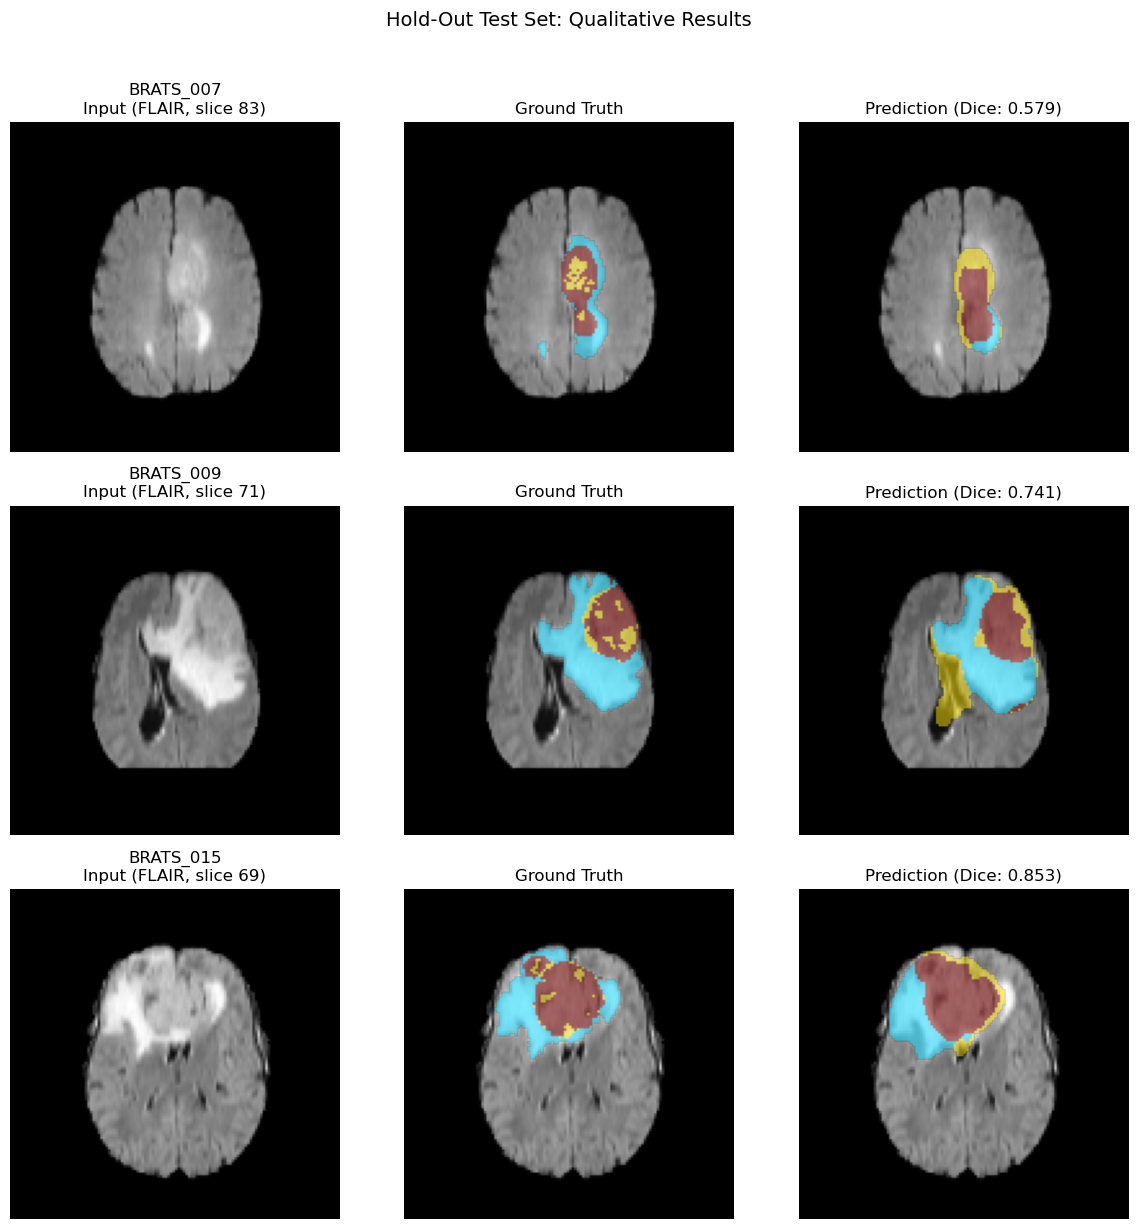


✓ These are TRUE held-out samples - never seen during training!


In [18]:
# ============================================================================
# VISUALIZE TEST SET PREDICTIONS
# ============================================================================
# Show qualitative results on held-out test samples

if len(test_samples) > 0 and DATA_MODE == "decathlon":
    print("Test Set Predictions (Qualitative Examples)")
    print("-" * 60)
    
    # Show up to 3 test samples
    n_show = min(3, len(test_samples))
    
    fig, axes = plt.subplots(n_show, 3, figsize=(12, 4*n_show))
    if n_show == 1:
        axes = axes.reshape(1, -1)
    
    for i, sample_path in enumerate(test_samples[:n_show]):
        case_id = sample_path.stem.replace('.nii', '')
        
        # Get prediction
        data, pred = predict_sample(model, sample_path, device, DATA_MODE, TARGET_SHAPE)
        
        # Get segmentation and resize if needed
        seg = data['seg']
        flair = data['flair']
        if TARGET_SHAPE is not None:
            from scipy.ndimage import zoom
            seg_zoom = [t / c for t, c in zip(TARGET_SHAPE, seg.shape)]
            flair_zoom = [t / c for t, c in zip(TARGET_SHAPE, flair.shape)]
            seg = zoom(seg, seg_zoom, order=0)
            flair = zoom(flair, flair_zoom, order=1)
        
        # Find slice with most tumor
        tumor_per_slice = np.sum(seg > 0, axis=(1, 2))
        best_slice = np.argmax(tumor_per_slice)
        
        # Plot FLAIR
        axes[i, 0].imshow(flair[best_slice].T, cmap='gray', origin='lower')
        axes[i, 0].set_title(f'{case_id}\nInput (FLAIR, slice {best_slice})')
        axes[i, 0].axis('off')
        
        # Plot Ground Truth
        axes[i, 1].imshow(flair[best_slice].T, cmap='gray', origin='lower')
        seg_slice = seg[best_slice].T
        masked_seg = np.ma.masked_where(seg_slice == 0, seg_slice)
        axes[i, 1].imshow(masked_seg, cmap='jet', alpha=0.5, origin='lower', vmin=0, vmax=3)
        axes[i, 1].set_title('Ground Truth')
        axes[i, 1].axis('off')
        
        # Plot Prediction
        axes[i, 2].imshow(flair[best_slice].T, cmap='gray', origin='lower')
        pred_slice = pred[best_slice].T
        masked_pred = np.ma.masked_where(pred_slice == 0, pred_slice)
        axes[i, 2].imshow(masked_pred, cmap='jet', alpha=0.5, origin='lower', vmin=0, vmax=3)
        
        # Get Dice for this sample
        sample_dice = test_results[i]['dice'] if i < len(test_results) else 'N/A'
        axes[i, 2].set_title(f'Prediction (Dice: {sample_dice:.3f})')
        axes[i, 2].axis('off')
    
    plt.suptitle('Hold-Out Test Set: Qualitative Results', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()
    
    print("\n✓ These are TRUE held-out samples - never seen during training!")

### Key Takeaways from Test Evaluation

1. **Unbiased Estimate**: The test set Dice score gives us an honest estimate of how the model will perform on truly new data.

2. **Generalization Gap**: The difference between validation and test performance indicates how much we've overfitted to our hyperparameter choices.

3. **Per-class Analysis**: Looking at per-class Dice scores helps identify which tumor types are hardest to segment.

4. **Reproducibility**: All case IDs and parameters are logged in the checkpoint file for reproducibility.

## 6. Inference and Visualization

In [19]:
def predict(model, sample_path, device, data_mode=DATA_MODE, target_shape=TARGET_SHAPE):
    """Run inference on a single sample."""
    model.eval()
    
    # Load data based on mode
    if data_mode == "decathlon":
        from src.data_utils import load_decathlon_sample
        data = load_decathlon_sample(sample_path)
        image = data['image']  # Already (4, D, H, W)
    else:
        data = load_mri_sample(sample_path)
        modalities = ['t1', 't1ce', 't2', 'flair']
        image = np.stack([normalize_volume(data[mod]) for mod in modalities], axis=0)
    
    # Normalize each channel
    for c in range(image.shape[0]):
        channel = image[c]
        mask = channel > 0
        if mask.sum() > 0:
            mean = channel[mask].mean()
            std = channel[mask].std() + 1e-8
            image[c] = np.where(mask, (channel - mean) / std, 0)
    
    # Resize if needed (for Decathlon data)
    if target_shape is not None:
        from scipy.ndimage import zoom
        current_shape = image.shape[1:]  # (D, H, W)
        zoom_factors = [t / c for t, c in zip(target_shape, current_shape)]
        image = np.stack([zoom(image[c], zoom_factors, order=1) for c in range(4)], axis=0)
    
    image_tensor = torch.from_numpy(image).float().unsqueeze(0).to(device)
    
    # Predict
    with torch.no_grad():
        output = model(image_tensor)
        pred = output.argmax(dim=1).squeeze().cpu().numpy()
    
    return data, pred

In [20]:
# Run inference on validation sample
sample_dir = val_samples[0]
data, prediction = predict(model, sample_dir, device)

print(f"Sample: {sample_dir.name}")
print(f"Prediction shape: {prediction.shape}")
print(f"Unique predicted classes: {np.unique(prediction)}")

Sample: BRATS_050.nii.gz
Prediction shape: (128, 128, 128)
Unique predicted classes: [0 1 2 3]


Resizing for visualization: (155, 240, 240) -> (128, 128, 128)


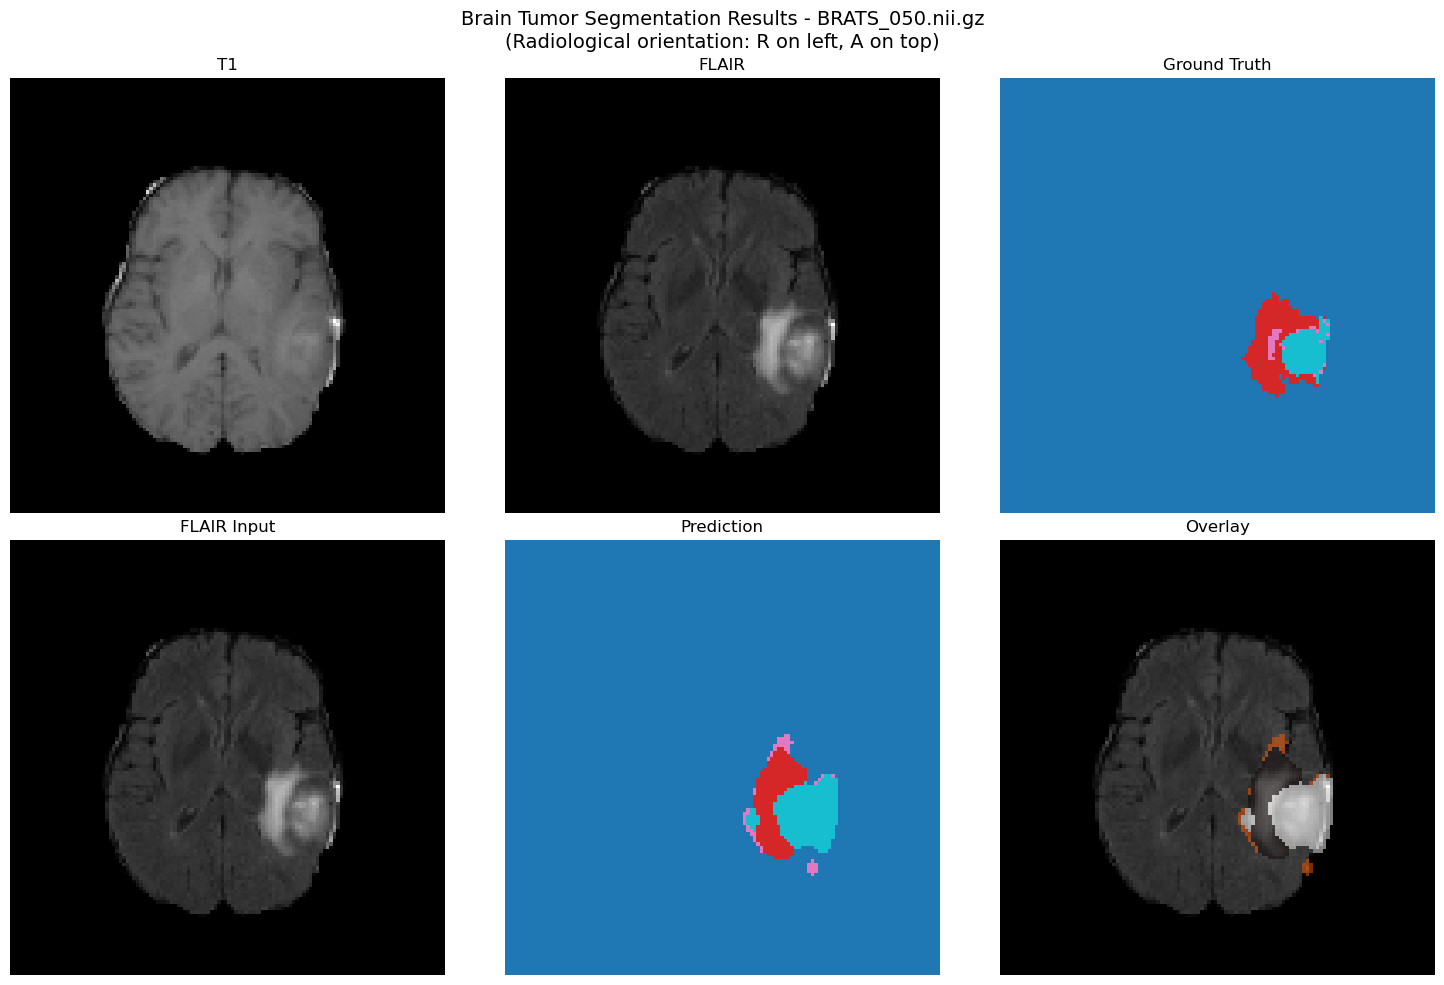

In [21]:
# Visualize results in radiological orientation (RAS convention)
# Patient's right appears on left side of image, anterior at top

def to_radiological(arr):
    """Convert axial slice to radiological orientation (R on left, A on top)."""
    # Rotate 90° CCW and flip for proper radiological orientation
    return np.fliplr(np.rot90(arr, k=1))

# Resize ground truth and original images to match prediction resolution if needed
from scipy.ndimage import zoom

orig_shape = data['seg'].shape
pred_shape = prediction.shape

if orig_shape != pred_shape:
    print(f"Resizing for visualization: {orig_shape} -> {pred_shape}")
    zoom_factors = [p / o for p, o in zip(pred_shape, orig_shape)]
    seg_resized = zoom(data['seg'].astype(float), zoom_factors, order=0).astype(int)  # nearest for labels
    flair_resized = zoom(data['flair'], zoom_factors, order=1)
    t1_resized = zoom(data['t1'], zoom_factors, order=1)
else:
    seg_resized = data['seg']
    flair_resized = data['flair']
    t1_resized = data['t1']

# Use middle slice of prediction shape
slice_idx = pred_shape[0] // 2

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Top row: MRI modalities (resized to match prediction)
axes[0, 0].imshow(to_radiological(t1_resized[slice_idx, :, :]), cmap='gray', origin='upper')
axes[0, 0].set_title('T1')
axes[0, 0].axis('off')

axes[0, 1].imshow(to_radiological(flair_resized[slice_idx, :, :]), cmap='gray', origin='upper')
axes[0, 1].set_title('FLAIR')
axes[0, 1].axis('off')

# Ground truth (resized)
axes[0, 2].imshow(to_radiological(seg_resized[slice_idx, :, :]), cmap='tab10', origin='upper', vmin=0, vmax=NUM_CLASSES-1)
axes[0, 2].set_title('Ground Truth')
axes[0, 2].axis('off')

# Bottom row: Prediction comparison
axes[1, 0].imshow(to_radiological(flair_resized[slice_idx, :, :]), cmap='gray', origin='upper')
axes[1, 0].set_title('FLAIR Input')
axes[1, 0].axis('off')

axes[1, 1].imshow(to_radiological(prediction[slice_idx, :, :]), cmap='tab10', origin='upper', vmin=0, vmax=NUM_CLASSES-1)
axes[1, 1].set_title('Prediction')
axes[1, 1].axis('off')

# Overlay
flair_slice = to_radiological(flair_resized[slice_idx, :, :])
pred_slice = to_radiological(prediction[slice_idx, :, :])
axes[1, 2].imshow(flair_slice, cmap='gray', origin='upper')
masked_pred = np.ma.masked_where(pred_slice == 0, pred_slice)
axes[1, 2].imshow(masked_pred, cmap='hot', alpha=0.5, origin='upper')
axes[1, 2].set_title('Overlay')
axes[1, 2].axis('off')

plt.suptitle(f'Brain Tumor Segmentation Results - {sample_dir.name}\n(Radiological orientation: R on left, A on top)', fontsize=14)
plt.tight_layout()
plt.show()

## 7. Evaluation Metrics

In [22]:
def compute_metrics(pred, target):
    """Compute segmentation metrics."""
    from scipy.ndimage import zoom
    
    # Resize target to match prediction if shapes differ
    if pred.shape != target.shape:
        zoom_factors = [p / t for p, t in zip(pred.shape, target.shape)]
        target = zoom(target.astype(float), zoom_factors, order=0).astype(int)  # nearest neighbor for labels
    
    # Combine all tumor classes (1, 2, 3) vs background (0)
    pred_tumor = (pred > 0).astype(float)
    target_tumor = (target > 0).astype(float)
    
    # Dice score (whole tumor)
    intersection = (pred_tumor * target_tumor).sum()
    dice = (2 * intersection + 1e-5) / (pred_tumor.sum() + target_tumor.sum() + 1e-5)
    
    # Sensitivity (recall) - how much of the tumor we detected
    tp = intersection
    fn = target_tumor.sum() - tp
    sensitivity = tp / (tp + fn + 1e-5)
    
    # Specificity - how well we identify non-tumor
    tn = ((pred == 0) & (target == 0)).sum()
    fp = pred_tumor.sum() - tp
    specificity = tn / (tn + fp + 1e-5)
    
    return {
        'dice': float(dice),
        'sensitivity': float(sensitivity),
        'specificity': float(specificity)
    }

In [23]:
# Evaluate on all samples
print("Evaluation Results")
print("=" * 50)

all_metrics = []
for sample_dir in samples:
    data, pred = predict(model, sample_dir, device)
    metrics = compute_metrics(pred, data['seg'])
    all_metrics.append(metrics)
    print(f"{sample_dir.name}: Dice={metrics['dice']:.4f}, "
          f"Sens={metrics['sensitivity']:.4f}, Spec={metrics['specificity']:.4f}")

print("=" * 50)
print(f"Mean Dice: {np.mean([m['dice'] for m in all_metrics]):.4f}")
print(f"Mean Sensitivity: {np.mean([m['sensitivity'] for m in all_metrics]):.4f}")
print(f"Mean Specificity: {np.mean([m['specificity'] for m in all_metrics]):.4f}")

Evaluation Results
BRATS_001.nii.gz: Dice=0.7662, Sens=0.9959, Spec=0.9924
BRATS_002.nii.gz: Dice=0.7850, Sens=0.9921, Spec=0.9962
BRATS_003.nii.gz: Dice=0.7519, Sens=0.9482, Spec=0.9887
BRATS_004.nii.gz: Dice=0.9108, Sens=0.9753, Spec=0.9977
BRATS_005.nii.gz: Dice=0.5946, Sens=0.4659, Spec=0.9991
BRATS_006.nii.gz: Dice=0.9016, Sens=0.9044, Spec=0.9975
BRATS_007.nii.gz: Dice=0.5793, Sens=0.7330, Spec=0.9946
BRATS_008.nii.gz: Dice=0.7371, Sens=0.9808, Spec=0.9855
BRATS_009.nii.gz: Dice=0.7409, Sens=0.9235, Spec=0.9864
BRATS_010.nii.gz: Dice=0.1125, Sens=0.0622, Spec=0.9999
BRATS_011.nii.gz: Dice=0.7997, Sens=0.9877, Spec=0.9926
BRATS_012.nii.gz: Dice=0.5459, Sens=0.7533, Spec=0.9976
BRATS_013.nii.gz: Dice=0.2073, Sens=0.3274, Spec=0.9973
BRATS_014.nii.gz: Dice=0.8566, Sens=0.9554, Spec=0.9954
BRATS_015.nii.gz: Dice=0.8535, Sens=0.9421, Spec=0.9940
BRATS_016.nii.gz: Dice=0.7204, Sens=0.8006, Spec=0.9961
BRATS_017.nii.gz: Dice=0.7208, Sens=0.7409, Spec=0.9964
BRATS_018.nii.gz: Dice=0.4599

## 8. Summary and Next Steps

In this notebook, we demonstrated a complete brain tumor segmentation pipeline following best practices:

### What We Covered

1. **Proper Experimental Design**:
   - Train/Validation/Test splits (70%/15%/15%)
   - Held-out test set for unbiased evaluation
   - Reproducibility through fixed random seeds

2. **Modern Training Techniques**:
   - Early stopping to prevent overfitting
   - Learning rate scheduling (ReduceLROnPlateau)
   - Comprehensive logging of training history

3. **Medical Imaging Specifics**:
   - Multiparametric MRI data (T1, T1ce, T2, FLAIR)
   - 3D U-Net architecture for volumetric segmentation
   - Dice loss for handling class imbalance
   - Per-class evaluation for multi-class segmentation

4. **Evaluation Best Practices**:
   - Separate validation vs. test evaluation
   - Dice score, sensitivity, specificity metrics
   - Comparison of validation vs. test performance

### Key Takeaways

- **Never tune hyperparameters on test data** - that's what validation is for
- **Report test set performance** - validation can be overly optimistic
- **Early stopping + best model restoration** = optimal generalization
- **Log everything** - reproducibility is critical in medical AI

### Further Improvements for Production

- Use larger datasets (full BraTS with 300+ cases)
- Implement sophisticated augmentation (elastic deformations, intensity variations)
- Use nnU-Net for state-of-the-art performance
- Add post-processing (connected component analysis, morphological operations)
- Implement k-fold cross-validation for more robust estimates

### References

- Ronneberger et al., "U-Net: Convolutional Networks for Biomedical Image Segmentation", MICCAI 2015
- Isensee et al., "nnU-Net: a self-configuring method for deep learning-based biomedical image segmentation", Nature Methods 2021
- Medical Segmentation Decathlon: http://medicaldecathlon.com/

In [24]:
# Save model (optional)
# torch.save(model.state_dict(), 'unet3d_brain_tumor.pth')
# print("Model saved!")

## **Optional:**

In [25]:
# ============================================================================
# SAVE TRAINED MODEL (run this cell to save your trained model)
# ============================================================================
save_path = Path("../models/pretrained/brain_tumor_unet3d.pt")
save_path.parent.mkdir(parents=True, exist_ok=True)

# Get best dice from history if available
best_dice = max(history.get('val_dice', [0])) if history.get('val_dice') else 0.0

checkpoint = {
    'epoch': len(history.get('train_loss', [])) or 20,
    'model_state_dict': model.state_dict(),
    'best_dice': best_dice,
    'history': history,
    'config': {
        'in_channels': 4,
        'out_channels': NUM_CLASSES,
        'base_features': 16,
        'depth': 3,
        'data_mode': DATA_MODE,
        'target_shape': TARGET_SHAPE,
    }
}

torch.save(checkpoint, save_path)
print(f"✓ Model saved to: {save_path}")
print(f"  File size: {save_path.stat().st_size / 1024 / 1024:.2f} MB")
print(f"  Best validation Dice: {best_dice:.4f}")
print(f"\nTo use this model, set USE_PRETRAINED = True in the configuration cell.")

✓ Model saved to: ../models/pretrained/brain_tumor_unet3d.pt
  File size: 5.40 MB
  Best validation Dice: 0.9909

To use this model, set USE_PRETRAINED = True in the configuration cell.
